# Лабораторная работа 3

# Анимация движения секущей прямой к заданной линии на плоскости

Гайкович Прохор, $23.03.2026$

## Задание 3.1. Анимированное построение линии на плоскости

а) $\color{red}\text{Создадим анимацию}$ построения графика некоторой явно заданной аналитической функции $y = y(x)$ по значениям $x$, последовательно изменяющимся от $x_{min}$ до $x_{max}$ с шагом $step$ для $y(x) = sin(x)^5$, $x_{min} = 1$, $x_{max}$, $step = 0.05$.

б) $\color{red}\text{Создадим анимацию}$ построения графика параметрической функции $x = x(t)$, $y = y(t)$ по значениям $t$, последовательно изменяющимся от $t_{min}$ до $t_{max}$ с шагом $step$. Выполним задание для функции из Задания 1.4 в Лб1, согласно моему варианту **6**. Значения $t_{min}$ и $t_{max}$ выберем самостоятельно с учетом непрерывности параметрической функции на выбранном диапазоне $step = (t_{max} - t_{min}) / 100$.
$$x = \cot(2e^t),\quad y = \ln(\tan\ e^t).$$

## Реализация Задания 3.1а
Импортируем `numpy` и `pyplot` из пакета `matplotlib`:

In [70]:
import numpy as np
import matplotlib.pyplot as plt

Импортируем функцию `FuncAnimation` из модуля `animation` пакета
`matplotlib`: 

In [71]:
from matplotlib.animation import FuncAnimation

Вызовем специальную команду JupyterLab, необходимую для корректного
отображения анимации в интерактивном документе

In [72]:
%matplotlib widget

Будем строить анимацию для функции вида $y(x) = sin(x)^5$ по значениям $x$, изменяющимся от $x_{min} = 1$ до $x_{max} = 5$ с шагом $step = 0.05$.

Определим функцию $y(x)$ с приминением оператора `def`:

In [73]:
def y(x):
    return np.sin(x) ** 5

Создадим переменные:

In [74]:
x_min = 1.; x_max = 5.; step = 0.05

Создадим массив `x_array` равномерно распределённых чисел на отрезке $[x_{min}, x_{max}]$ с шагом $step$ с помощью функции `arange`. Создадим массив `y_array` соответствующих значений $y$ с помощью пользовательской функции `y`:

In [75]:
x_array = np.arange(x_min, x_max, step)
y_array = y(x_array)

Из двух массивов `x_array` и `y_array` создадим матрицу `matrix` координат точек графика функции $y(x)$. Матрица состоит из двух столбцов. Первый столбец матрицы содержит $x$-координаты точек, второй столбец — $y$-координаты точек:

In [76]:
matrix = np.transpose([x_array, y_array])

С помощью функции `figure` из модуля `pyplot` создадим графическое окно `fig1`, в котором в дальнейшем будет отображаться анимация:

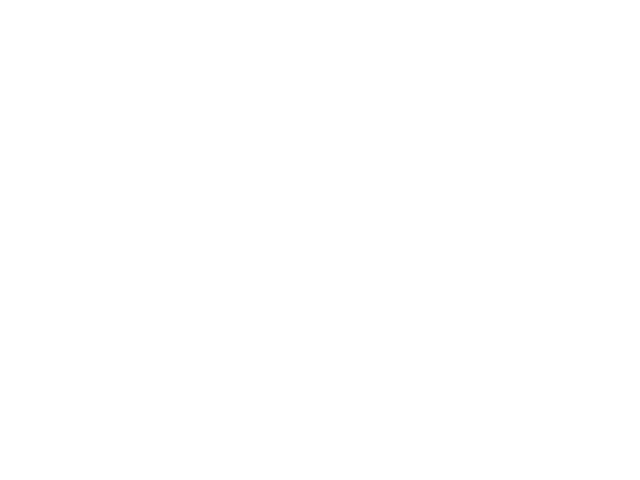

In [77]:
fig1 = plt.figure()

С помощью функции `axes` из модуля `pyplot` создадим графическую область `ax1` и зададим для неё пределы по осям:

In [78]:
y_min, y_max = np.min(y_array), np.max(y_array)

ax1 = plt.axes()
plt.axis([x_min - 0.1, x_max + 0.1, y_min - 0.1, y_max + 0.1]);

С помощью функции `plot` из пакета `pyplot` создадим в графической области `ax1` графический объект типа `Line2D` синего цвета, координаты которого пока не определены:

In [79]:
line1, = ax1.plot([], [], "b")
print(type(line1))
line1.get_xdata(), line1.get_ydata()

<class 'matplotlib.lines.Line2D'>


(array([], dtype=float64), array([], dtype=float64))

In [80]:
?line1.get_xdata

Signature: line1.get_xdata(orig=True)
Docstring:
Return the xdata.

If *orig* is *True*, return the original data, else the
processed data.
File:      c:\users\uladz\anaconda3\lib\site-packages\matplotlib\lines.py
Type:      method

Определим пользовательскую функцию одного аргумента `at_frame1`, которая будет вызываться в каждом кадре анимации.

Единственный аргумент функции `at_frame1` является массивом из $x$ и $y$ координат точки графика функции. Функция `at_frame1` добавляет к графическому объекту `line1` точку с координатами $(x, y)$:

In [81]:
def at_frame1(point):
    """Добавляет к объекту line1 точку с координатами (points[0], points[1])
    
    Arguments :

    point : массив из двух элементов
    
    Returns : None
    """
    x_coord = list(line1.get_xdata())
    y_coord = list(line1.get_ydata())
    
    x_coord.append(point[0])
    y_coord.append(point[1])

    line1.set_data(x_coord, y_coord)

In [82]:
?line1.set_data

Signature: line1.set_data(*args)
Docstring:
Set the x and y data.

Parameters
----------
*args : (2, N) array or two 1D arrays

See Also
--------
set_xdata
set_ydata
File:      c:\users\uladz\anaconda3\lib\site-packages\matplotlib\lines.py
Type:      method

In [83]:
help(at_frame1)

Help on function at_frame1 in module __main__:

at_frame1(point)
    Добавляет к объекту line1 точку с координатами (points[0], points[1])

    Arguments :

    point : массив из двух элементов

    Returns : None



In [84]:
?at_frame1

Signature: at_frame1(point)
Docstring:
Добавляет к объекту line1 точку с координатами (points[0], points[1])

Arguments :

point : массив из двух элементов

Returns : None
File:      c:\users\uladz\appdata\local\temp\ipykernel_16052\3374943427.py
Type:      function

In [85]:
print(at_frame1.__doc__)

Добавляет к объекту line1 точку с координатами (points[0], points[1])

Arguments :

point : массив из двух элементов

Returns : None



Для построения анимации полагаем аргумент `frames` для функции `FuncAnimation` следующим образом: `frames=matrix`. Это означает, что количество кадров анимации будет совпадать с количеством строк матрицы `matrix`. При этом для каждого кадра анимации будет вызываться функция `at_frame1` со значением аргумента, равным строке матрицы `matrix`, индекс которой соответствует номеру кадра.

$\color{red}\text{Важная информация для построения анимации}$: вызовы функций `figure`, `axes`, `plot`, необходимых для анимации, а также вызов функции `FuncAnimation` должны располагаться в одной ячейке кода.

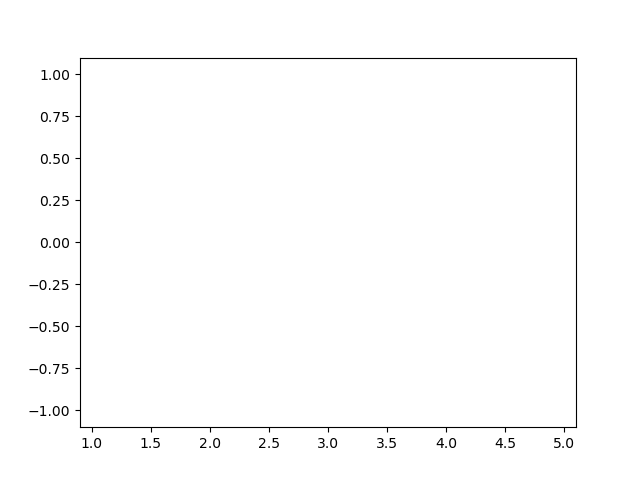

In [86]:
fig1 = plt.figure()
ax1 = plt.axes()
plt.axis([x_min - 0.1, x_max + 0.1, y_min - 0.1, y_max + 0.1])

line1, = ax1.plot([], [], "b")

anim = FuncAnimation(fig1, at_frame1, frames=matrix, repeat=False, interval=1)

Для повторного воспроизведения анимации нужно запустить предыдующую ячейку кода снова.

В результате многочисленных запусков анимации может накопиться много объектов графических окон. Функция `close` удалит это объекты

In [87]:
plt.close("all")

## Реализация Задания 3.1б

Реализуем анимацию для 
$$x = \cot(2e^t),\quad y = \ln(\tan\ e^t).$$

Для начала зададим данные:

In [98]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

x = lambda t: 1 / np.tan(2 * np.exp(t))
y = lambda t: np.log(np.tan(np.exp(t)))

t_min = -5
t_max = -2
step = 0.01

t_array = np.arange(t_min, t_max, step)
x_array = x(t_array)
y_array = y(t_array)

matrix = np.transpose([x_array, y_array])

x_min, x_max = np.min(x_array), np.max(x_array)
y_min, y_max = np.min(y_array), np.max(y_array)

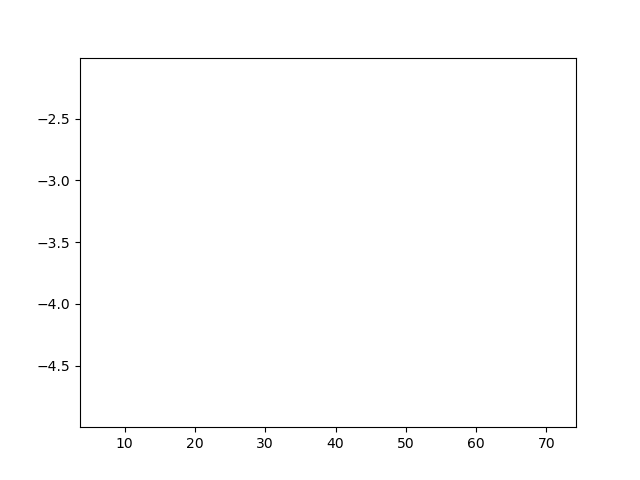

In [99]:
fig = plt.figure()
ax = plt.axes()

plt.axis([x_min, x_max, y_min, y_max])

line, = plt.plot([], [], "b-")

def at_frame(point):
    """Добавляет к объекту line точку с координатами (points[0], points[1])
    
    Arguments :

    point : массив из двух элементов
    
    Returns : None
    """
    x_coord = list(line.get_xdata())
    y_coord = list(line.get_ydata())
    
    x_coord.append(point[0])
    y_coord.append(point[1])

    line.set_data(x_coord, y_coord)

anim = FuncAnimation(fig, at_frame, frames=matrix, repeat=False, interval=1)

In [100]:
plt.close("all")

## Задание 3.2. Движение точки по линии на плоскости
$\color{red}\text{Создадим анимацию}$ движения точки по графику функции $x = x(t)$, $y = y(t)$ по значениям $t$, последовательно изменяющимся от $t_{min}$ до $t_{max}$ с шагом $step$. Функцию $x = x(t)$, $y = y(t)$ и значения переменных $t_{min}$, $t_{max}$, $step$ зададим такими же, как и при выполнении задания 3.1б.
$$x = \cot(2e^t),\quad y = \ln(\tan\ e^t).$$

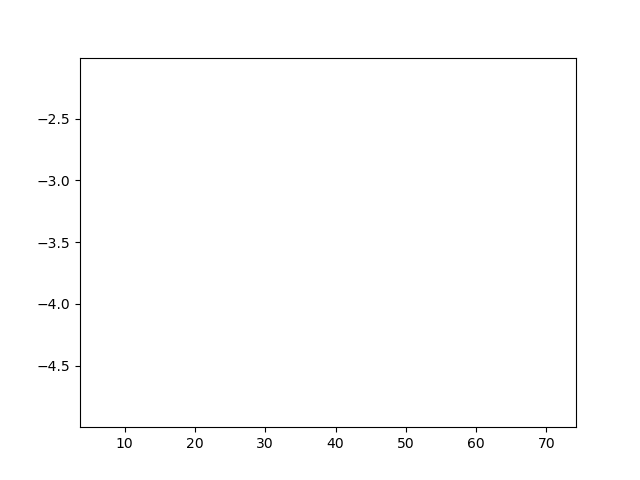

In [101]:
fig, ax = plt.subplots()
plt.axis([x_min, x_max, y_min, y_max])

def update(frame):
    """обновляет положение точки
    
    Arguments : 
    
    frame : массив из двух элементов
    
    Returns : None
    """
    point.set_data([frame[0]], [frame[1]])

def init():
    """создает начальное состояние графической области"""
    
    global point
    line, = ax.plot(x_array, y_array, 'b')
    point, = ax.plot([], [], 'go')
    plt.legend([r'$x = \cot(2e^t),\ y = \ln(\tan e^t)$', 'Movable point'])

anim = FuncAnimation(fig, update, frames=matrix,
                     init_func=init, repeat=False, interval=20)

In [102]:
plt.close("all")

## Задание 3.3. Движение секущей прямой к заданной линии на плоскости

Линия на плоскости задана графиком параметрической функции $x = x(t)$, $y = y(t)$ для $t \in [t_{min}, t_{max}]$ из Задания 3.1б. Начальная точка $A$ с координатами $(x(t_{min}), y(t_{min}))$ является неподвижной точкой. Точка $B$ движется последовательно по линии от конечной точки кривой с координатами $(x(t_{max}), y(t_{max}))$ к неподвижной точке $A$.

$\color{red}\text{Создадим анимацию}$ движения секущей прямой, проходящей через $A$ и $B$ до момента совпадении координат точек $A$ и $B$, когда секущая прямая становится касательной прямой к заданной линии в начальной точке $A$.

Вначале импортируем `sympy`, зададим производные и найдем производную в минимальной и максимальной точках:

In [103]:
import sympy as sp

t_sym = sp.Symbol("t")
x_sym = sp.cot(2 * sp.exp(t_sym))
y_sym = sp.ln(sp.tan(sp.exp(t_sym)))

dx_dt = sp.diff(x_sym, t_sym)
dy_dt = sp.diff(y_sym, t_sym)
dy_dx_sym = dy_dt / dx_dt
dy_dx_func = sp.lambdify(t_sym, dy_dx_sym, 'numpy')

slope_at_A = dy_dx_func(t_min)
slope_at_B = dy_dx_func(t_max)

А теперь перейдём к реализации:

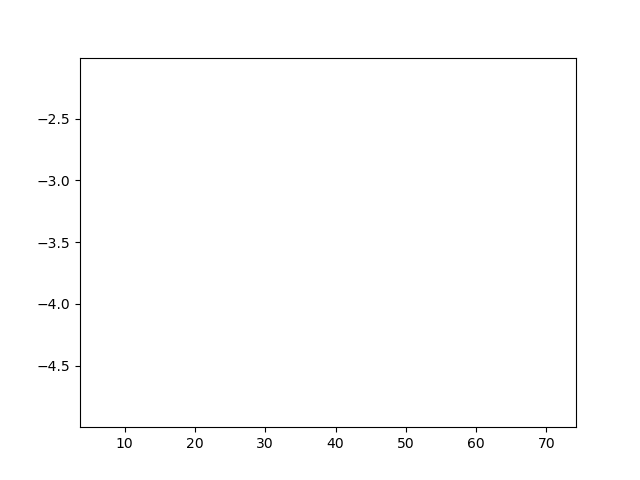

In [119]:
fig, ax = plt.subplots()
plt.axis([x_min, x_max, y_min, y_max])

def init():
    """создаёт начальное состояние графической области перед началом анимации"""

    global point_B, secant_line, tangent_line, A, B
    
    init_fig, = ax.plot(x_array, y_array, "b")

    A = np.array([x_array[0], y_array[0]])
    point_A = ax.plot(A[0], A[1], "ro")

    B = np.array([x_array[-1], y_array[-1]])
    point_B, = ax.plot(B[0], B[1], "go")

    secant_p = [A + (B - A) * t for t in [-2, 2]]
    secant_p = np.array(secant_p)
    secant_line, = ax.plot(secant_p[:,0], secant_p[:,1], "g")

    tangent_line, = ax.plot([], [], "r")

    ax.legend([r'$x = \cot(2e^t),\ y = \ln(\tan e^t)$', 'Unmovable point A',
                'Мovable point B', 'Secant line', 'Tangent line'])

def at_frame3(point):
    """изменяет состояние точки B и секущей линии secant_line,
    при достижении точкой B точки A заменняет секущею линию на касательную tangent_line
    
    Arguments :

    point : массив из двух элементов

    Returns : None
    """
    global point_B, secant_line, tangent_line, A, B

    point_B.set_data([point[0]], [point[1]])

    dist = np.linalg.norm(point - A)
    eps = 1e-6
    
    if dist < eps:
        x_vals = np.array([x_min, x_max])
        y_vals = A[1] + slope_at_A * (x_vals - A[0])

        tangent_line.set_data(x_vals, y_vals)
        
        secant_line.set_data([], [])
    else:
        secant_p = [A + (point - A) * t for t in [-25, 25]]
        secant_p = np.array(secant_p)
        secant_line.set_data(secant_p[:,0], secant_p[:,1])

        tangent_line.set_data([], [])
        
    B = point
    
    
anim = FuncAnimation(fig, at_frame3, frames=matrix[::-1],
                     init_func=init, repeat=False, interval=1)

In [120]:
plt.close("all")

## Задание 3.4. Движение секущей прямой к заданной линии на плоскости (версия 2)
Линия на плоскости задана графиком параметрической функции $x = x(t)$, $y = y(t)$ для $t \in [t_{min}, t_{max}]$ из Задания 3.1б. Начальная точка $A$ с координатами $(x(t_{min}), y(t_{min}))$ является подвижной точкой на заданной линии, точка $B$ с координатами $(x(t_{max}), y(t_{max}))$ является неподвижной точкой $A$. Точка $A$ движется последовательнопо кривой до неподвижной точки $B$.

$\color{red}\text{Создадим анимацию}$ движения секущей прямой, проходящей через точки $A$ и $B$ до момента совпадения координат точек $A$ и $B$, когда секущая прямая становится касательной прямой к заданной линии в конечной точке  $B$. Вычисление производной в точке $B$, необходимое для построения касательной прямой, осуществим с помощью возможностей модуля `sympy`. Касательную прямую $\color{red}\text{изобразим}$ красным цветом

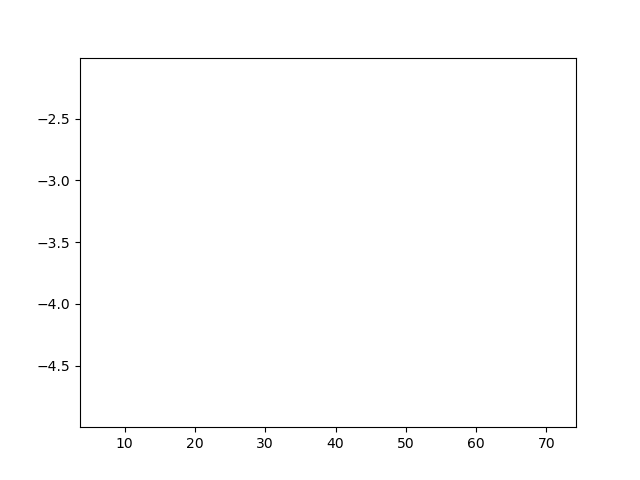

In [118]:
fig, ax = plt.subplots()
plt.axis([x_min, x_max, y_min, y_max])

def init():
    """создаёт начальное состояние графической области перед началом анимации"""

    global point_A, secant_line, tangent_line, A, B
    
    init_fig, = ax.plot(x_array, y_array, "b")

    B = np.array([x_array[-1], y_array[-1]])
    point_B, = ax.plot(B[0], B[1], "go")

    A = np.array([x_array[0], y_array[0]])
    point_A, = ax.plot(A[0], A[1], "ro")

    secant_p = [A + (B - A) * t for t in [-2, 2]]
    secant_p = np.array(secant_p)
    secant_line, = ax.plot(secant_p[:,0], secant_p[:,1], "g")

    tangent_line, = ax.plot([], [], "r")

    ax.legend([r'$x = \cot(2e^t),\ y = \ln(\tan e^t)$', 'Unmovable point B',
                'Мovable point A', 'Secant line', 'Tangent line'])

    return point_A, secant_line, tangent_line


def update(point):
    """изменяет состояние точки A и секущей линии secant_line,
    при достижении точкой A точки B заменняет секущею линию на касательную tangent_line
    
    Arguments :

    point : массив из двух элементов

    Returns : None
    """
    global point_A, secant_line, tangent_line, A, B

    point_A.set_data([point[0]], [point[1]])

    dist = np.linalg.norm(point - B)
    eps = 1e-6
    
    if dist < eps:
        x_vals = np.array([x_min, x_max])
        y_vals = B[1] + slope_at_B * (x_vals - B[0])

        tangent_line.set_data(x_vals, y_vals)
        
        secant_line.set_data([], [])
    else:
        secant_p = np.array([B + (point - B) * t for t in [-25, 25]])
        secant_p = np.array(secant_p)
        secant_line.set_data(secant_p[:,0], secant_p[:,1])

        tangent_line.set_data([], [])

    return point_A, secant_line, tangent_line
    
anim = FuncAnimation(fig, update, frames=matrix,
                     init_func=init, repeat=False, interval=1, blit=True) 

In [121]:
plt.close("all")

### Конец!